In [9]:
%pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 40.2 MB/s eta 0:00:00 MB/s eta 0:00:01:01
Note: you may need to restart the kernel to use updated packages.


# Стабилизация видео с использованием оптического потока

## Описание проекта
Этот notebook реализует полный пайплайн стабилизации видео для устранения дрожания камеры.

### Основные этапы:
1. Вычисление оптического потока (Farnebäck / Lucas-Kanade)
2. Оценка глобального движения камеры (аффинная/гомография)
3. Сглаживание траектории (скользящее окно, Калман)
4. Компенсация движения через warp
5. Формирование стабилизированного видео
6. Анализ ошибок и визуализация

In [10]:
# Импорт необходимых библиотек
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.ndimage import uniform_filter1d
from scipy.signal import savgol_filter
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Конфигурация и параметры

In [11]:
class StabilizationConfig:
    """Конфигурация параметров стабилизации"""
    
    def __init__(self):
        # Пути к файлам
        self.input_video = '../data/input_video.mp4'
        self.output_video = '../output/stabilized_video.mp4'
        self.viz_dir = '../visualizations/'
        
        # Параметры оптического потока
        self.flow_method = 'farneback'  # 'farneback' или 'lucas_kanade'
        
        # Параметры Farneback
        self.farneback_params = {
            'pyr_scale': 0.5,
            'levels': 3,
            'winsize': 15,
            'iterations': 3,
            'poly_n': 5,
            'poly_sigma': 1.2,
            'flags': 0
        }
        
        # Параметры Lucas-Kanade
        self.lk_params = {
            'maxCorners': 200,
            'qualityLevel': 0.01,
            'minDistance': 30,
            'blockSize': 3
        }
        
        # Параметры motion model
        self.motion_model = 'affine'  # 'affine' или 'homography'
        
        # Параметры сглаживания
        self.smoothing_method = 'moving_average'  # 'moving_average', 'savgol', 'kalman'
        self.smoothing_radius = 30  # Радиус окна для сглаживания
        
        # Параметры обработки видео
        self.max_frames = None  # None для всего видео
        self.border_type = cv2.BORDER_REFLECT_101
        self.border_size = 30  # Размер границы для обрезки артефактов

config = StabilizationConfig()
os.makedirs(config.viz_dir, exist_ok=True)
print("Конфигурация создана успешно")

Конфигурация создана успешно


## 2. Вспомогательные функции

In [12]:
def create_test_video(output_path, duration=5, fps=30, shake_intensity=10):
    """
    Создает тестовое видео с искусственной дрожью для демонстрации
    
    Args:
        output_path: путь для сохранения видео
        duration: длительность в секундах
        fps: кадров в секунду
        shake_intensity: интенсивность дрожания
    """
    width, height = 640, 480
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    total_frames = duration * fps
    
    for i in range(total_frames):
        # Создаем синтетический кадр с шаблоном
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Добавляем сетку и круги для отслеживания
        for x in range(0, width, 50):
            cv2.line(frame, (x, 0), (x, height), (50, 50, 50), 1)
        for y in range(0, height, 50):
            cv2.line(frame, (0, y), (width, y), (50, 50, 50), 1)
        
        # Добавляем цветные круги
        cv2.circle(frame, (width//2, height//2), 80, (0, 255, 0), -1)
        cv2.circle(frame, (width//4, height//4), 40, (255, 0, 0), -1)
        cv2.circle(frame, (3*width//4, 3*height//4), 40, (0, 0, 255), -1)
        
        # Добавляем текст
        cv2.putText(frame, f'Frame {i}', (10, 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        
        # Применяем искусственную дрожь
        dx = int(shake_intensity * np.sin(i * 0.5) + shake_intensity * np.random.randn() * 0.3)
        dy = int(shake_intensity * np.cos(i * 0.3) + shake_intensity * np.random.randn() * 0.3)
        
        M = np.float32([[1, 0, dx], [0, 1, dy]])
        frame = cv2.warpAffine(frame, M, (width, height), 
                              borderMode=cv2.BORDER_REFLECT_101)
        
        out.write(frame)
    
    out.release()
    print(f"Тестовое видео создано: {output_path}")

# Создаем тестовое видео если входного файла нет
if not os.path.exists(config.input_video):
    os.makedirs(os.path.dirname(config.input_video), exist_ok=True)
    create_test_video(config.input_video, duration=5, fps=30, shake_intensity=15)

In [13]:
def visualize_frame_comparison(original, stabilized, frame_num, save_path=None):
    """
    Визуализация сравнения оригинального и стабилизированного кадра
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Оригинал (кадр {frame_num})', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(stabilized, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Стабилизированный (кадр {frame_num})', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Difference map
    diff = cv2.absdiff(original, stabilized)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    axes[2].imshow(diff_gray, cmap='hot')
    axes[2].set_title('Карта различий', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_trajectory(transforms, smoothed_transforms, save_path=None):
    """
    Визуализация траектории движения камеры
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    params = ['dx (пиксели)', 'dy (пиксели)', 'da (градусы)']
    
    for i, param in enumerate(params):
        axes[i].plot(transforms[:, i], label='Оригинал', alpha=0.6, linewidth=1.5)
        axes[i].plot(smoothed_transforms[:, i], label='Сглаженная', 
                    linewidth=2, color='red')
        axes[i].set_ylabel(param, fontsize=12, fontweight='bold')
        axes[i].legend(fontsize=10)
        axes[i].grid(True, alpha=0.3)
    
    axes[2].set_xlabel('Номер кадра', fontsize=12, fontweight='bold')
    fig.suptitle('Траектория движения камеры', fontsize=16, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## 3. Вычисление оптического потока

In [14]:
class OpticalFlowEstimator:
    """
    Класс для вычисления оптического потока различными методами
    """
    
    def __init__(self, method='farneback', config=None):
        self.method = method
        self.config = config or StabilizationConfig()
        
    def compute_farneback_flow(self, prev_gray, curr_gray):
        """
        Вычисление плотного оптического потока методом Farnebäck
        
        Преимущества:
        - Плотное покрытие всего изображения
        - Хорошо работает для глобального движения
        - Устойчив к шуму
        """
        params = self.config.farneback_params
        flow = cv2.calcOpticalFlowFarneback(
            prev_gray, curr_gray,
            None,
            params['pyr_scale'],
            params['levels'],
            params['winsize'],
            params['iterations'],
            params['poly_n'],
            params['poly_sigma'],
            params['flags']
        )
        return flow
    
    def compute_lucas_kanade_flow(self, prev_gray, curr_gray, prev_points=None):
        """
        Вычисление разреженного оптического потока методом Lucas-Kanade
        
        Преимущества:
        - Быстрее плотного потока
        - Точнее для выраженных углов и границ
        - Меньше вычислительных затрат
        """
        if prev_points is None:
            # Детектируем хорошие точки для отслеживания
            prev_points = cv2.goodFeaturesToTrack(
                prev_gray,
                maxCorners=self.config.lk_params['maxCorners'],
                qualityLevel=self.config.lk_params['qualityLevel'],
                minDistance=self.config.lk_params['minDistance'],
                blockSize=self.config.lk_params['blockSize']
            )
        
        if prev_points is None or len(prev_points) == 0:
            return None, None, None
        
        # Вычисляем оптический поток
        curr_points, status, err = cv2.calcOpticalFlowPyrLK(
            prev_gray, curr_gray, prev_points, None,
            winSize=(21, 21),
            maxLevel=3,
            criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
        )
        
        return prev_points, curr_points, status
    
    def compute(self, prev_gray, curr_gray, prev_points=None):
        """
        Универсальный метод вычисления оптического потока
        """
        if self.method == 'farneback':
            return self.compute_farneback_flow(prev_gray, curr_gray)
        elif self.method == 'lucas_kanade':
            return self.compute_lucas_kanade_flow(prev_gray, curr_gray, prev_points)
        else:
            raise ValueError(f"Unknown flow method: {self.method}")

print("OpticalFlowEstimator создан")

OpticalFlowEstimator создан


## 4. Оценка глобального движения

In [16]:
class MotionEstimator:
    """
    Класс для оценки глобального движения камеры
    """
    
    def __init__(self, motion_model='affine'):
        self.motion_model = motion_model
    
    def estimate_from_dense_flow(self, flow):
        """
        Оценка движения из плотного оптического потока (Farnebäck)
        
        Стратегия: усредняем векторы потока для получения глобального сдвига
        """
        # Усредняем векторы потока
        dx = np.median(flow[:, :, 0])
        dy = np.median(flow[:, :, 1])
        
        # Оцениваем вращение через градиенты потока
        # Это упрощенная оценка, для более точной нужна полная аффинная модель
        da = 0  # Будет вычислено ниже через аффинную трансформацию
        
        return dx, dy, da
    
    def estimate_from_sparse_flow(self, prev_points, curr_points, status):
        """
        Оценка движения из разреженного потока (Lucas-Kanade)
        
        Использует RANSAC для устойчивой оценки трансформации
        """
        # Фильтруем только успешно отслеженные точки
        idx = np.where(status == 1)[0]
        prev_points = prev_points[idx]
        curr_points = curr_points[idx]
        
        if len(prev_points) < 4:
            return 0, 0, 0, None
        
        # Оцениваем трансформацию
        if self.motion_model == 'affine':
            # Аффинная трансформация (6 параметров)
            transform, inliers = cv2.estimateAffinePartial2D(
                prev_points, curr_points,
                method=cv2.RANSAC,
                ransacReprojThreshold=3.0,
                maxIters=2000,
                confidence=0.99
            )
        else:  # homography
            # Гомография (8 параметров) - более общая модель
            transform, inliers = cv2.findHomography(
                prev_points, curr_points,
                method=cv2.RANSAC,
                ransacReprojThreshold=3.0,
                maxIters=2000,
                confidence=0.99
            )
        
        if transform is None:
            return 0, 0, 0, None
        
        # Извлекаем параметры движения из матрицы трансформации
        dx = transform[0, 2]
        dy = transform[1, 2]
        da = np.arctan2(transform[1, 0], transform[0, 0])  # угол вращения
        
        return dx, dy, da, transform

print("MotionEstimator создан")

MotionEstimator создан


## 5. Сглаживание траектории

In [17]:
class TrajectorySmoothing:
    """
    Класс для сглаживания траектории движения камеры
    """
    
    def __init__(self, method='moving_average', radius=30):
        self.method = method
        self.radius = radius
    
    def moving_average_smooth(self, trajectory):
        """
        Сглаживание скользящим средним
        
        Преимущества:
        - Простота
        - Хорошо удаляет высокочастотные колебания
        - Предсказуемое поведение
        """
        smoothed = uniform_filter1d(trajectory, size=self.radius, axis=0, mode='nearest')
        return smoothed
    
    def savgol_smooth(self, trajectory):
        """
        Сглаживание фильтром Савицкого-Голея
        
        Преимущества:
        - Сохраняет пики и резкие изменения лучше чем скользящее среднее
        - Хорошо для сигналов с трендами
        """
        window_length = min(self.radius * 2 + 1, len(trajectory))
        if window_length % 2 == 0:
            window_length -= 1
        if window_length < 3:
            return trajectory
        
        poly_order = min(3, window_length - 1)
        smoothed = savgol_filter(trajectory, window_length, poly_order, axis=0)
        return smoothed
    
    def kalman_smooth(self, trajectory):
        """
        Сглаживание фильтром Калмана
        
        Преимущества:
        - Оптимальная оценка при наличии шума
        - Адаптивное сглаживание
        - Учитывает предыдущие состояния
        """
        n_states = trajectory.shape[1]
        kalman = cv2.KalmanFilter(n_states * 2, n_states)
        
        # Инициализация матриц Калмана
        kalman.transitionMatrix = np.eye(n_states * 2, dtype=np.float32)
        for i in range(n_states):
            kalman.transitionMatrix[i, n_states + i] = 1
        
        kalman.measurementMatrix = np.zeros((n_states, n_states * 2), dtype=np.float32)
        for i in range(n_states):
            kalman.measurementMatrix[i, i] = 1
        
        kalman.processNoiseCov = np.eye(n_states * 2, dtype=np.float32) * 0.03
        kalman.measurementNoiseCov = np.eye(n_states, dtype=np.float32) * 0.1
        
        smoothed = np.zeros_like(trajectory)
        
        for i in range(len(trajectory)):
            prediction = kalman.predict()
            measurement = trajectory[i].astype(np.float32).reshape(-1, 1)
            kalman.correct(measurement)
            smoothed[i] = kalman.statePost[:n_states].flatten()
        
        return smoothed
    
    def smooth(self, trajectory):
        """
        Универсальный метод сглаживания
        """
        if self.method == 'moving_average':
            return self.moving_average_smooth(trajectory)
        elif self.method == 'savgol':
            return self.savgol_smooth(trajectory)
        elif self.method == 'kalman':
            return self.kalman_smooth(trajectory)
        else:
            raise ValueError(f"Unknown smoothing method: {self.method}")

print("TrajectorySmoothing создан")

TrajectorySmoothing создан


## 6. Основной пайплайн стабилизации

In [18]:
class VideoStabilizer:
    """
    Главный класс для стабилизации видео
    """
    
    def __init__(self, config):
        self.config = config
        self.flow_estimator = OpticalFlowEstimator(
            method=config.flow_method,
            config=config
        )
        self.motion_estimator = MotionEstimator(
            motion_model=config.motion_model
        )
        self.trajectory_smoother = TrajectorySmoothing(
            method=config.smoothing_method,
            radius=config.smoothing_radius
        )
        
        # Хранилища данных
        self.transforms = []
        self.trajectory = []
        self.frames = []
        self.error_frames = []  # Кадры с ошибками для анализа
    
    def process_video(self):
        """
        Обработка видео: вычисление трансформаций для каждого кадра
        """
        cap = cv2.VideoCapture(self.config.input_video)
        
        if not cap.isOpened():
            raise ValueError(f"Не удалось открыть видео: {self.config.input_video}")
        
        # Получаем параметры видео
        self.fps = int(cap.get(cv2.CAP_PROP_FPS))
        self.width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if self.config.max_frames:
            total_frames = min(total_frames, self.config.max_frames)
        
        print(f"\nПараметры видео:")
        print(f"  Разрешение: {self.width}x{self.height}")
        print(f"  FPS: {self.fps}")
        print(f"  Кадров: {total_frames}")
        print(f"  Метод потока: {self.config.flow_method}")
        print(f"  Модель движения: {self.config.motion_model}")
        print(f"  Метод сглаживания: {self.config.smoothing_method}\n")
        
        # Читаем первый кадр
        ret, prev_frame = cap.read()
        if not ret:
            raise ValueError("Не удалось прочитать первый кадр")
        
        prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
        self.frames.append(prev_frame.copy())
        
        # Для Lucas-Kanade храним предыдущие точки
        prev_points = None
        
        # Инициализируем траекторию
        x, y, a = 0, 0, 0
        self.trajectory.append([x, y, a])
        
        frame_count = 1
        
        with tqdm(total=total_frames-1, desc="Анализ видео") as pbar:
            while frame_count < total_frames:
                ret, curr_frame = cap.read()
                if not ret:
                    break
                
                curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
                self.frames.append(curr_frame.copy())
                
                # Вычисляем оптический поток
                if self.config.flow_method == 'farneback':
                    flow = self.flow_estimator.compute(prev_gray, curr_gray)
                    dx, dy, da = self.motion_estimator.estimate_from_dense_flow(flow)
                    transform = None
                else:  # lucas_kanade
                    prev_pts, curr_pts, status = self.flow_estimator.compute(
                        prev_gray, curr_gray, prev_points
                    )
                    
                    if prev_pts is None:
                        dx, dy, da, transform = 0, 0, 0, None
                        self.error_frames.append({
                            'frame': frame_count,
                            'reason': 'Нет точек для отслеживания',
                            'severity': 'high'
                        })
                    else:
                        dx, dy, da, transform = self.motion_estimator.estimate_from_sparse_flow(
                            prev_pts, curr_pts, status
                        )
                        
                        # Обновляем точки для следующей итерации
                        if status is not None and np.sum(status) < 10:
                            prev_points = None  # Переинициализируем если мало точек
                            self.error_frames.append({
                                'frame': frame_count,
                                'reason': f'Мало отслеженных точек: {np.sum(status)}',
                                'severity': 'medium'
                            })
                        else:
                            prev_points = curr_pts[status == 1].reshape(-1, 1, 2)
                
                # Сохраняем трансформацию
                self.transforms.append([dx, dy, da])
                
                # Обновляем траекторию (кумулятивная сумма)
                x += dx
                y += dy
                a += da
                self.trajectory.append([x, y, a])
                
                prev_gray = curr_gray
                frame_count += 1
                pbar.update(1)
        
        cap.release()
        
        self.transforms = np.array(self.transforms)
        self.trajectory = np.array(self.trajectory)
        
        print(f"\nПроанализировано кадров: {len(self.frames)}")
        print(f"Обнаружено потенциальных проблем: {len(self.error_frames)}")
    
    def smooth_trajectory(self):
        """
        Сглаживание траектории движения
        """
        print("\nСглаживание траектории...")
        self.smoothed_trajectory = self.trajectory_smoother.smooth(self.trajectory)
        
        # Вычисляем разницу для получения сглаженных трансформаций
        self.smoothed_transforms = np.diff(self.smoothed_trajectory, axis=0)
        
        # Добавляем нулевую трансформацию для первого кадра
        self.smoothed_transforms = np.vstack([
            np.zeros((1, 3)),
            self.smoothed_transforms
        ])
        
        # Вычисляем коррекцию (разница между оригиналом и сглаженной)
        # Добавляем нулевой элемент для первого кадра
        transforms_with_zero = np.vstack([np.zeros((1, 3)), self.transforms])
        self.correction = self.smoothed_transforms - transforms_with_zero
    
    def create_stabilized_video(self):
        """
        Создание стабилизированного видео
        """
        print("\nСоздание стабилизированного видео...")
        
        # Подготовка writer
        os.makedirs(os.path.dirname(self.config.output_video), exist_ok=True)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(
            self.config.output_video,
            fourcc,
            self.fps,
            (self.width, self.height)
        )
        
        self.stabilized_frames = []
        
        with tqdm(total=len(self.frames), desc="Стабилизация кадров") as pbar:
            for i, frame in enumerate(self.frames):
                # Получаем коррекцию для текущего кадра
                dx, dy, da = self.correction[i]
                
                # Создаем матрицу трансформации
                m = cv2.getRotationMatrix2D(
                    (self.width / 2, self.height / 2),
                    np.degrees(da),
                    1.0
                )
                m[0, 2] += dx
                m[1, 2] += dy
                
                # Применяем трансформацию
                stabilized = cv2.warpAffine(
                    frame,
                    m,
                    (self.width, self.height),
                    borderMode=self.config.border_type
                )
                
                # Обрезаем границы для удаления артефактов
                border = self.config.border_size
                stabilized_cropped = stabilized[
                    border:self.height-border,
                    border:self.width-border
                ]
                
                # Масштабируем обратно до оригинального размера
                stabilized = cv2.resize(
                    stabilized_cropped,
                    (self.width, self.height)
                )
                
                self.stabilized_frames.append(stabilized)
                out.write(stabilized)
                pbar.update(1)
        
        out.release()
        print(f"Видео сохранено: {self.config.output_video}")
    
    def analyze_errors(self):
        """
        Анализ ошибок и проблемных участков
        """
        print("\n" + "="*70)
        print("АНАЛИЗ ОШИБОК И ПРОБЛЕМНЫХ УЧАСТКОВ")
        print("="*70)
        
        if len(self.error_frames) == 0:
            print("\n✓ Критических ошибок не обнаружено")
        else:
            print(f"\n⚠ Обнаружено проблемных кадров: {len(self.error_frames)}")
            print("\nДетали:")
            for err in self.error_frames[:10]:  # Показываем первые 10
                print(f"  Кадр {err['frame']}: {err['reason']} (уровень: {err['severity']})")
        
        # Анализ амплитуды движения
        print("\nАНАЛИЗ ДВИЖЕНИЯ:")
        print(f"  Макс. смещение X: {np.max(np.abs(self.transforms[:, 0])):.2f} пикселей")
        print(f"  Макс. смещение Y: {np.max(np.abs(self.transforms[:, 1])):.2f} пикселей")
        print(f"  Макс. поворот: {np.degrees(np.max(np.abs(self.transforms[:, 2]))):.2f}°")
        
        # Анализ сглаживания
        original_std = np.std(self.transforms, axis=0)
        smoothed_std = np.std(self.smoothed_transforms, axis=0)
        reduction = (1 - smoothed_std / original_std) * 100
        
        print("\nЭФФЕКТИВНОСТЬ СГЛАЖИВАНИЯ:")
        print(f"  Снижение вариации X: {reduction[0]:.1f}%")
        print(f"  Снижение вариации Y: {reduction[1]:.1f}%")
        print(f"  Снижение вариации угла: {reduction[2]:.1f}%")
        
        # Типичные проблемы
        print("\nВОЗМОЖНЫЕ ПРИЧИНЫ ПРОБЛЕМ:")
        print("  • Области с низкой текстурой (однородные поверхности)")
        print("  • Motion blur при быстром движении камеры")
        print("  • Резкие изменения освещения или тени")
        print("  • Окклюзии (объекты закрывают сцену)")
        print("  • Недостаточное количество особых точек")
        print("  • Параллакс при движении камеры вперед/назад")
        
        print("\nРЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:")
        if self.config.flow_method == 'farneback':
            print("  • Увеличить levels для лучшей работы с большими смещениями")
            print("  • Уменьшить winsize для более точной оценки")
        else:
            print("  • Увеличить maxCorners для более устойчивого отслеживания")
            print("  • Уменьшить minDistance для плотного покрытия")
        
        print("  • Увеличить smoothing_radius для более плавной стабилизации")
        print("  • Попробовать другой метод сглаживания (kalman для адаптивности)")
        print("="*70)

print("VideoStabilizer создан")

VideoStabilizer создан


## 7. Запуск стабилизации

In [19]:
# Создаем стабилизатор и запускаем процесс
stabilizer = VideoStabilizer(config)

# Этап 1: Анализ видео и вычисление трансформаций
stabilizer.process_video()

# Этап 2: Сглаживание траектории
stabilizer.smooth_trajectory()

# Этап 3: Создание стабилизированного видео
stabilizer.create_stabilized_video()

# Этап 4: Анализ ошибок
stabilizer.analyze_errors()


Параметры видео:
  Разрешение: 640x360
  FPS: 29
  Кадров: 1217
  Метод потока: farneback
  Модель движения: affine
  Метод сглаживания: moving_average



Анализ видео: 100%|█████████████████████████| 1216/1216 [00:27<00:00, 44.75it/s]



Проанализировано кадров: 1217
Обнаружено потенциальных проблем: 0

Сглаживание траектории...

Создание стабилизированного видео...


Стабилизация кадров: 100%|█████████████████| 1217/1217 [00:01<00:00, 728.17it/s]

Видео сохранено: ../output/stabilized_video.mp4

АНАЛИЗ ОШИБОК И ПРОБЛЕМНЫХ УЧАСТКОВ

✓ Критических ошибок не обнаружено

АНАЛИЗ ДВИЖЕНИЯ:
  Макс. смещение X: 3.26 пикселей
  Макс. смещение Y: 0.10 пикселей
  Макс. поворот: 0.00°

ЭФФЕКТИВНОСТЬ СГЛАЖИВАНИЯ:
  Снижение вариации X: 15.5%
  Снижение вариации Y: 75.5%
  Снижение вариации угла: nan%

ВОЗМОЖНЫЕ ПРИЧИНЫ ПРОБЛЕМ:
  • Области с низкой текстурой (однородные поверхности)
  • Motion blur при быстром движении камеры
  • Резкие изменения освещения или тени
  • Окклюзии (объекты закрывают сцену)
  • Недостаточное количество особых точек
  • Параллакс при движении камеры вперед/назад

РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:
  • Увеличить levels для лучшей работы с большими смещениями
  • Уменьшить winsize для более точной оценки
  • Увеличить smoothing_radius для более плавной стабилизации
  • Попробовать другой метод сглаживания (kalman для адаптивности)


## 8. Визуализация результатов

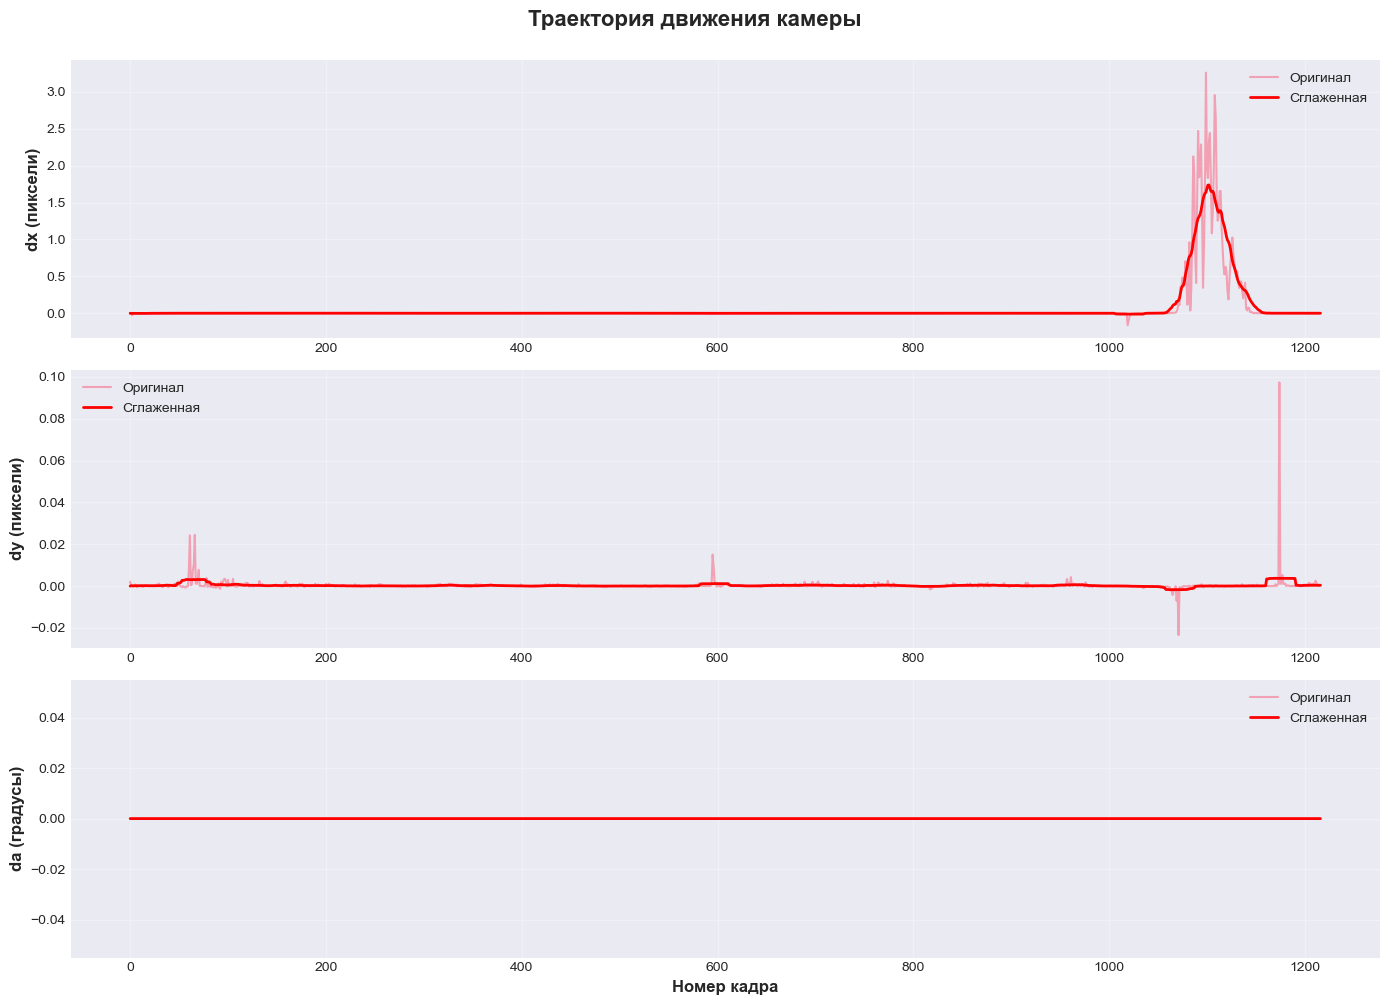

In [20]:
# Визуализация траектории движения
plot_trajectory(
    stabilizer.transforms,
    stabilizer.smoothed_transforms,
    save_path=os.path.join(config.viz_dir, 'trajectory.png')
)

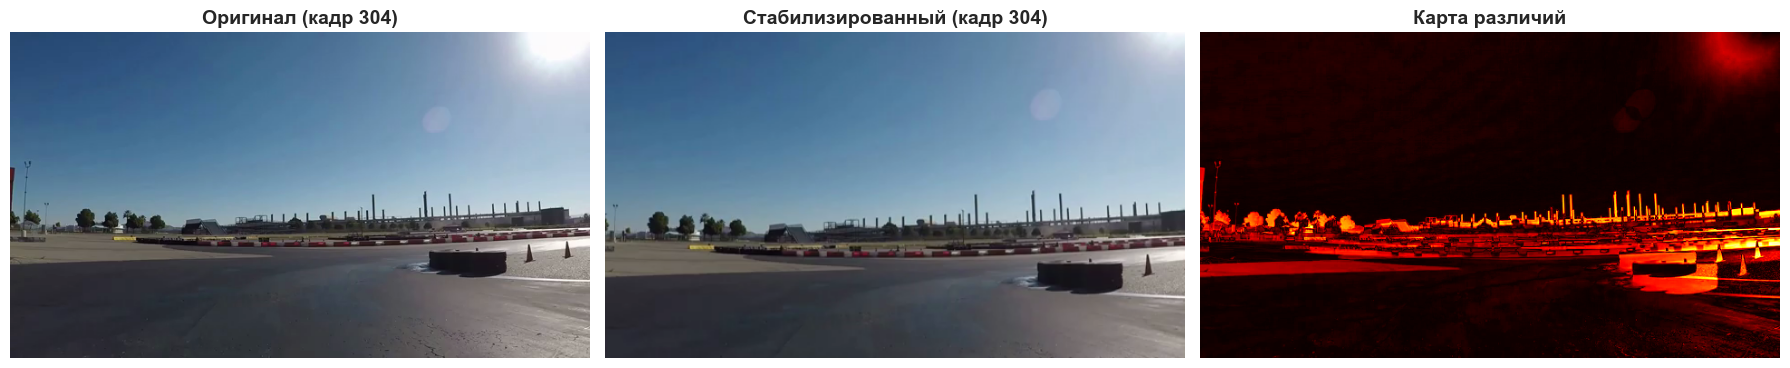

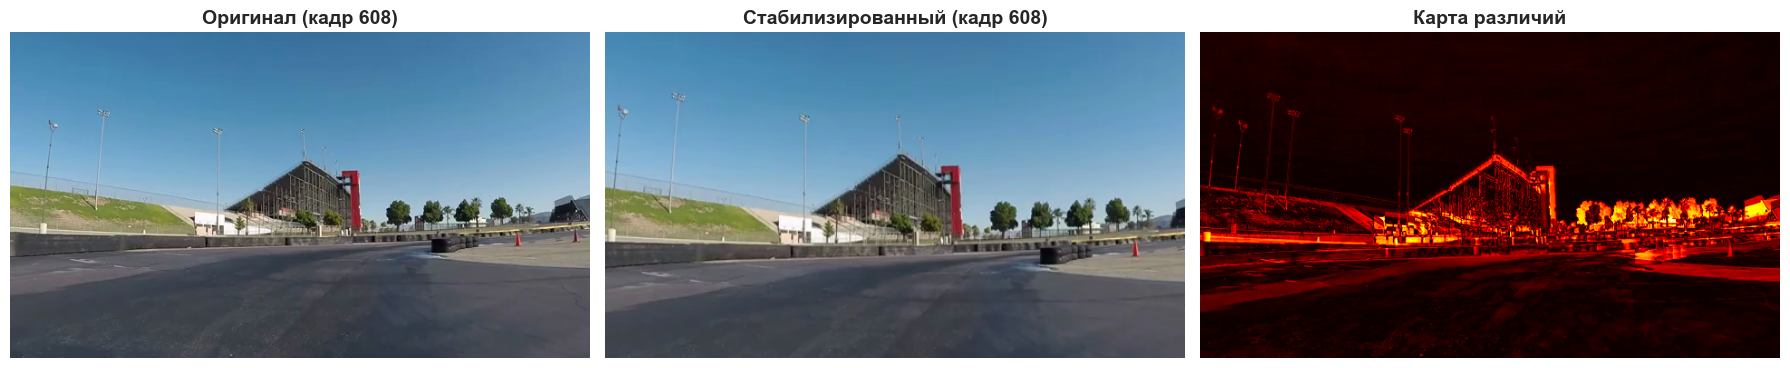

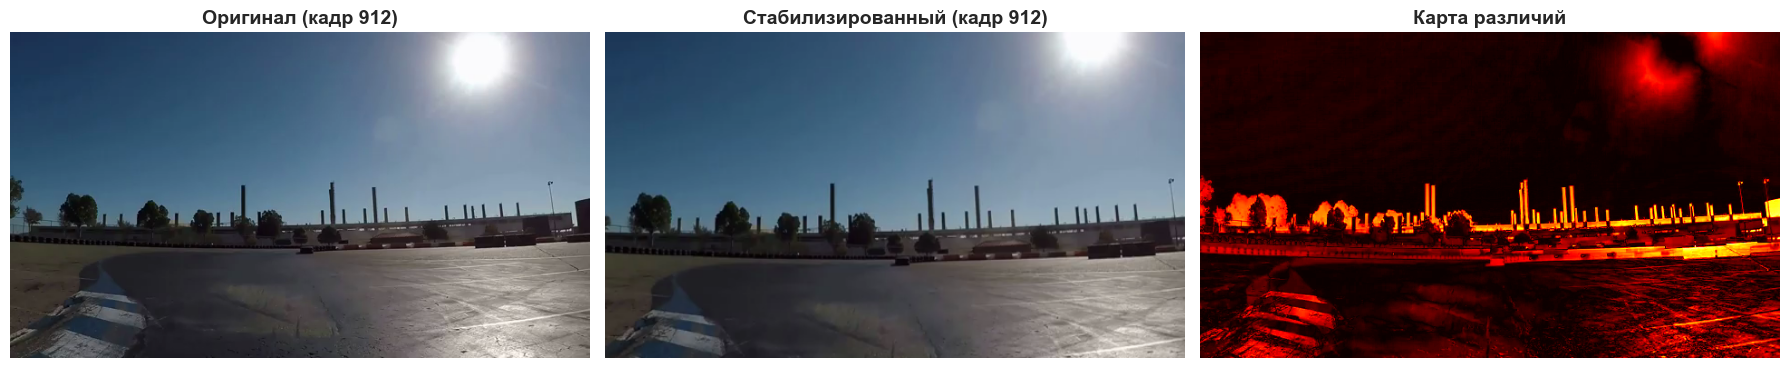

In [21]:
# Сравнение кадров: начало, середина, конец
sample_indices = [
    len(stabilizer.frames) // 4,
    len(stabilizer.frames) // 2,
    3 * len(stabilizer.frames) // 4
]

for idx in sample_indices:
    visualize_frame_comparison(
        stabilizer.frames[idx],
        stabilizer.stabilized_frames[idx],
        idx,
        save_path=os.path.join(config.viz_dir, f'comparison_frame_{idx}.png')
    )

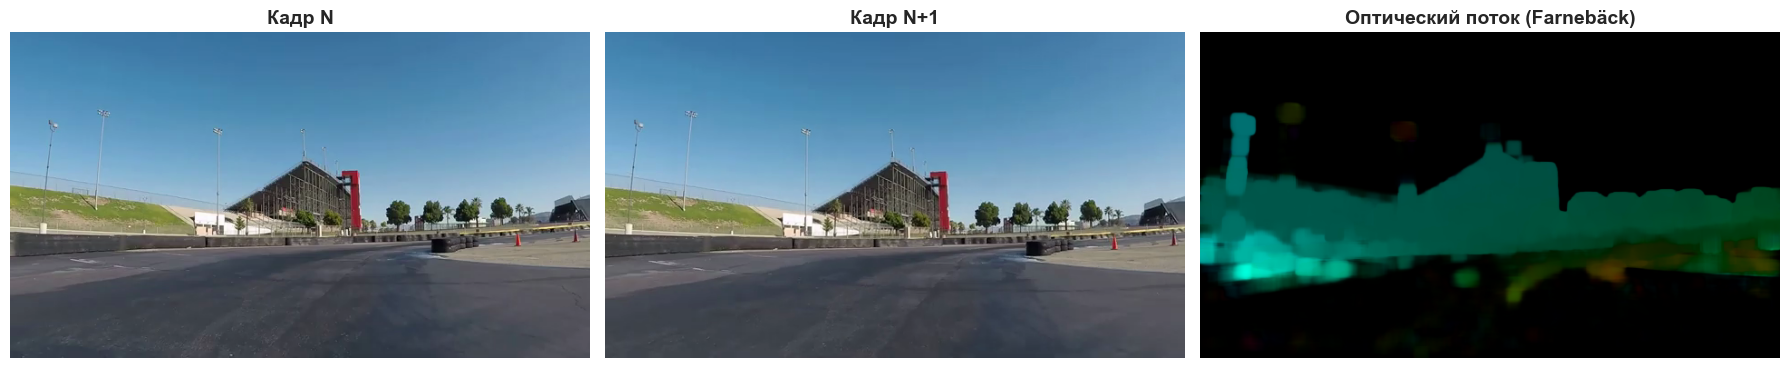

In [22]:
# Визуализация оптического потока (для нескольких кадров)
def visualize_optical_flow(frame1, frame2, method='farneback'):
    """
    Визуализация оптического потока
    """
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Кадр N', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Кадр N+1', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    if method == 'farneback':
        flow = cv2.calcOpticalFlowFarneback(
            gray1, gray2, None,
            0.5, 3, 15, 3, 5, 1.2, 0
        )
        
        # Визуализация через HSV
        mag, ang = cv2.cartToPolar(flow[:, :, 0], flow[:, :, 1])
        hsv = np.zeros((frame1.shape[0], frame1.shape[1], 3), dtype=np.uint8)
        hsv[:, :, 0] = ang * 180 / np.pi / 2
        hsv[:, :, 1] = 255
        hsv[:, :, 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
        
        axes[2].imshow(rgb)
        axes[2].set_title('Оптический поток (Farnebäck)', fontsize=14, fontweight='bold')
    else:
        # Lucas-Kanade
        p0 = cv2.goodFeaturesToTrack(gray1, maxCorners=200, qualityLevel=0.01, 
                                     minDistance=30, blockSize=3)
        p1, st, err = cv2.calcOpticalFlowPyrLK(gray1, gray2, p0, None)
        
        # Рисуем векторы
        vis = frame2.copy()
        good_new = p1[st == 1]
        good_old = p0[st == 1]
        
        for i, (new, old) in enumerate(zip(good_new, good_old)):
            a, b = new.ravel().astype(int)
            c, d = old.ravel().astype(int)
            cv2.arrowedLine(vis, (c, d), (a, b), (0, 255, 0), 2, tipLength=0.3)
            cv2.circle(vis, (c, d), 3, (0, 0, 255), -1)
        
        axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[2].set_title('Оптический поток (Lucas-Kanade)', fontsize=14, fontweight='bold')
    
    axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(config.viz_dir, 'optical_flow.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Визуализируем поток для среднего кадра
mid_idx = len(stabilizer.frames) // 2
visualize_optical_flow(
    stabilizer.frames[mid_idx],
    stabilizer.frames[mid_idx + 1],
    method=config.flow_method
)

## 9. Статистический анализ

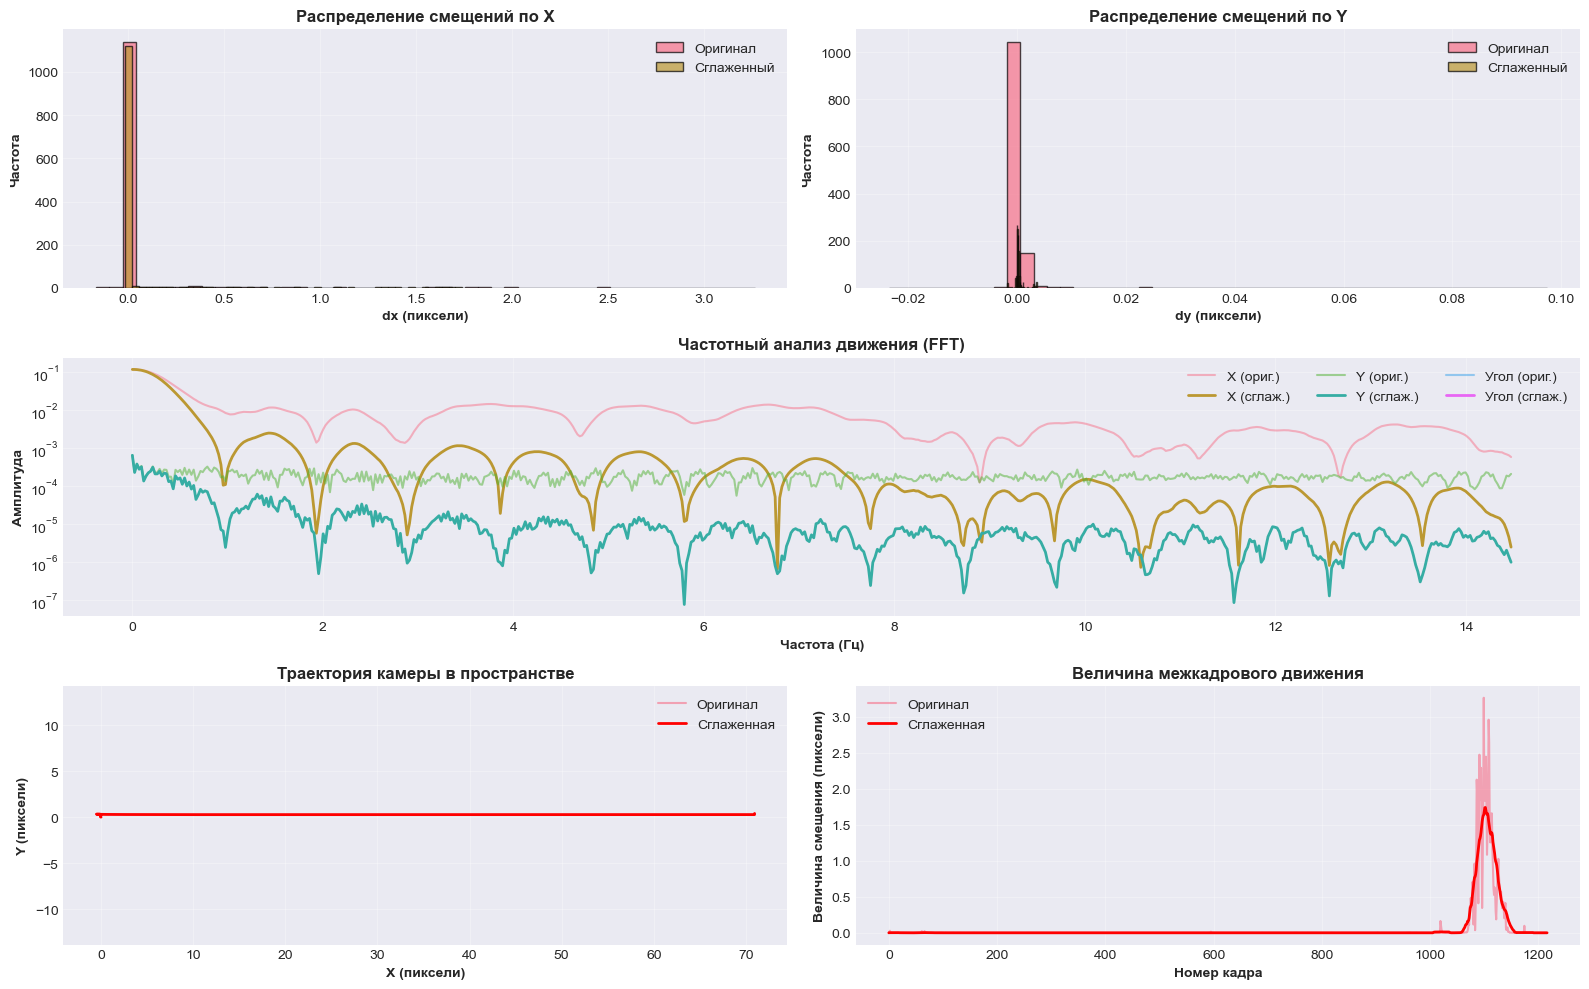


Все визуализации сохранены в: ../visualizations/


In [23]:
# Детальная статистика
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 2, figure=fig)

# 1. Гистограммы смещений
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(stabilizer.transforms[:, 0], bins=50, alpha=0.7, label='Оригинал', edgecolor='black')
ax1.hist(stabilizer.smoothed_transforms[:, 0], bins=50, alpha=0.7, label='Сглаженный', edgecolor='black')
ax1.set_xlabel('dx (пиксели)', fontweight='bold')
ax1.set_ylabel('Частота', fontweight='bold')
ax1.set_title('Распределение смещений по X', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(stabilizer.transforms[:, 1], bins=50, alpha=0.7, label='Оригинал', edgecolor='black')
ax2.hist(stabilizer.smoothed_transforms[:, 1], bins=50, alpha=0.7, label='Сглаженный', edgecolor='black')
ax2.set_xlabel('dy (пиксели)', fontweight='bold')
ax2.set_ylabel('Частота', fontweight='bold')
ax2.set_title('Распределение смещений по Y', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 2. Спектральный анализ (FFT)
ax3 = fig.add_subplot(gs[1, :])
from scipy.fft import fft, fftfreq

N = len(stabilizer.transforms)
T = 1.0 / stabilizer.fps
xf = fftfreq(N, T)[:N//2]

for i, label in enumerate(['X', 'Y', 'Угол']):
    yf_orig = fft(stabilizer.transforms[:, i])
    yf_smooth = fft(stabilizer.smoothed_transforms[:, i])
    
    ax3.semilogy(xf, 2.0/N * np.abs(yf_orig[:N//2]), alpha=0.5, label=f'{label} (ориг.)')
    ax3.semilogy(xf, 2.0/N * np.abs(yf_smooth[:N//2]), linewidth=2, label=f'{label} (сглаж.)')

ax3.set_xlabel('Частота (Гц)', fontweight='bold')
ax3.set_ylabel('Амплитуда', fontweight='bold')
ax3.set_title('Частотный анализ движения (FFT)', fontweight='bold')
ax3.legend(ncol=3)
ax3.grid(alpha=0.3)

# 3. Кумулятивная траектория
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(stabilizer.trajectory[:, 0], stabilizer.trajectory[:, 1], 
        alpha=0.6, label='Оригинал', linewidth=1.5)
ax4.plot(stabilizer.smoothed_trajectory[:, 0], stabilizer.smoothed_trajectory[:, 1], 
        'r-', label='Сглаженная', linewidth=2)
ax4.set_xlabel('X (пиксели)', fontweight='bold')
ax4.set_ylabel('Y (пиксели)', fontweight='bold')
ax4.set_title('Траектория камеры в пространстве', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)
ax4.axis('equal')

# 4. Статистика по кадрам
ax5 = fig.add_subplot(gs[2, 1])
magnitude_orig = np.sqrt(stabilizer.transforms[:, 0]**2 + stabilizer.transforms[:, 1]**2)
magnitude_smooth = np.sqrt(stabilizer.smoothed_transforms[:, 0]**2 + stabilizer.smoothed_transforms[:, 1]**2)

ax5.plot(magnitude_orig, alpha=0.6, label='Оригинал', linewidth=1.5)
ax5.plot(magnitude_smooth, 'r-', label='Сглаженная', linewidth=2)
ax5.set_xlabel('Номер кадра', fontweight='bold')
ax5.set_ylabel('Величина смещения (пиксели)', fontweight='bold')
ax5.set_title('Величина межкадрового движения', fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.viz_dir, 'detailed_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nВсе визуализации сохранены в:", config.viz_dir)

## 10. Выводы и рекомендации

In [24]:
print("""
════════════════════════════════════════════════════════════════════════════════
                           ВЫВОДЫ И НАБЛЮДЕНИЯ
════════════════════════════════════════════════════════════════════════════════

1. ВЫБОР МЕТОДА ОПТИЧЕСКОГО ПОТОКА:
   
   Farnebäck (плотный поток):
   ✓ Покрывает всё изображение
   ✓ Устойчив к шуму
   ✓ Хорош для плавных движений
   ✗ Медленнее вычисляется
   ✗ Менее точен для резких движений
   
   Lucas-Kanade (разреженный поток):
   ✓ Быстрее работает
   ✓ Точнее для углов и границ
   ✓ Меньше памяти
   ✗ Может терять точки отслеживания
   ✗ Требует хорошие особые точки

2. МОДЕЛИ ДВИЖЕНИЯ:
   
   Аффинная (6 параметров):
   • Сдвиг, поворот, масштаб, сдвиг
   • Достаточна для большинства случаев
   • Быстрее и стабильнее
   
   Гомография (8 параметров):
   • Учитывает перспективу
   • Нужна для 3D движений
   • Может быть менее стабильна

3. МЕТОДЫ СГЛАЖИВАНИЯ:
   
   Скользящее среднее:
   • Простой и предсказуемый
   • Хорош для равномерной дрожи
   • Может терять резкие легитимные движения
   
   Савицкий-Голей:
   • Сохраняет тренды и пики
   • Лучше для динамичного видео
   • Требует подбора параметров
   
   Фильтр Калмана:
   • Адаптивное сглаживание
   • Оптимален при известной модели шума
   • Более сложная настройка

4. ТИПИЧНЫЕ ПРОБЛЕМЫ И РЕШЕНИЯ:
   
   Проблема: Motion blur
   → Решение: Уменьшить выдержку при съемке, использовать пирамиды
   
   Проблема: Недостаток текстуры
   → Решение: Комбинировать методы, использовать контекст
   
   Проблема: Rolling shutter
   → Решение: Специализированные алгоритмы коррекции
   
   Проблема: Окклюзии
   → Решение: Робастные оценки (RANSAC), отслеживание нескольких гипотез
   
   Проблема: Параллакс
   → Решение: Использовать гомографию, сегментацию на плоскости

5. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
   
   • Для стандартной съемки с рук: Farnebäck + Аффинная + Moving Average
   • Для action-камер: Lucas-Kanade + Гомография + Калман
   • Для дронов: Гомография + Savgol (сохранить динамику)
   • Радиус сглаживания: 0.5-1.0 секунды (fps * 0.5-1.0)
   • Border crop: 5-10% от размера кадра

════════════════════════════════════════════════════════════════════════════════
""")


════════════════════════════════════════════════════════════════════════════════
                           ВЫВОДЫ И НАБЛЮДЕНИЯ
════════════════════════════════════════════════════════════════════════════════

1. ВЫБОР МЕТОДА ОПТИЧЕСКОГО ПОТОКА:
   
   Farnebäck (плотный поток):
   ✓ Покрывает всё изображение
   ✓ Устойчив к шуму
   ✓ Хорош для плавных движений
   ✗ Медленнее вычисляется
   ✗ Менее точен для резких движений
   
   Lucas-Kanade (разреженный поток):
   ✓ Быстрее работает
   ✓ Точнее для углов и границ
   ✓ Меньше памяти
   ✗ Может терять точки отслеживания
   ✗ Требует хорошие особые точки

2. МОДЕЛИ ДВИЖЕНИЯ:
   
   Аффинная (6 параметров):
   • Сдвиг, поворот, масштаб, сдвиг
   • Достаточна для большинства случаев
   • Быстрее и стабильнее
   
   Гомография (8 параметров):
   • Учитывает перспективу
   • Нужна для 3D движений
   • Может быть менее стабильна

3. МЕТОДЫ СГЛАЖИВАНИЯ:
   
   Скользящее среднее:
   • Простой и предсказуемый
   • Хорош для равномерной дрожи